<a href="https://colab.research.google.com/github/popcorn0125/Solar_energy_prediction/blob/main/AI_DX_EDU_%ED%83%9C%EC%96%91%EA%B4%91_%EC%A0%84%EB%A0%A5_%EC%83%9D%EC%82%B0%EB%9F%89_%EC%98%88%EC%B8%A1_%EB%AA%A8%EB%8D%B8_%ED%95%99%EC%8A%B5_%EB%B0%8F_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10. 최종 검증: 2024년 데이터로 학습하고, 2023년 맞추기 (Backtesting)

이 단계에서는 **과거 테스트(Backtesting)** 기법을 사용하여 모델의 실력을 냉정하게 평가합니다.

### 📋 검증 전략
1.  **학습 (Train)**: 2024년 1월 ~ 12월 전체 데이터 (`final_dataset.csv`)
    * AI에게 2024년의 봄, 여름, 가을, 겨울 패턴을 모두 가르칩니다.
2.  **평가 (Test)**: 2023년 데이터 (`final_test_2023.csv`)
    * 학습에 전혀 사용되지 않은 2023년 과거 데이터를 예측하게 하여, 모델이 미지의 날씨에도 잘 적응하는지 확인합니다. (2월 제외)

### ⚠️ 단위 통일
* 2024년 데이터는 MWh 단위로 저장되어 있으므로, 로드 후 **kWh로 변환**합니다.
* 2023년 데이터는 이미 kWh로 변환되어 있으므로 그대로 사용합니다.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Colab용)
# 실행 후 '런타임 다시 시작'을 해야 할 수도 있습니다.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

데이터 로드 중...
학습 데이터(2024): 8783개
검증 데이터(2023): 8087개 (2월 제외됨)

모델 학습 시작 (2024년 전체 데이터)...
학습 완료!
2023년 데이터 예측 중...

  [최종 성적표: 2023년 백테스팅 결과] 
 ----------------------------------------
 1. 결정 계수 (R2 Score): -2280385.8065
 2. 평균 오차 (RMSE)    : 18128.92 kWh (대구 전체)

[우리 집(3kW) 기준 예상 오차]
▶ RMSE: 0.8636 kWh
  (해석: 2023년 과거를 예측해본 결과, 시간당 약 0.86kWh 정도 틀립니다.)


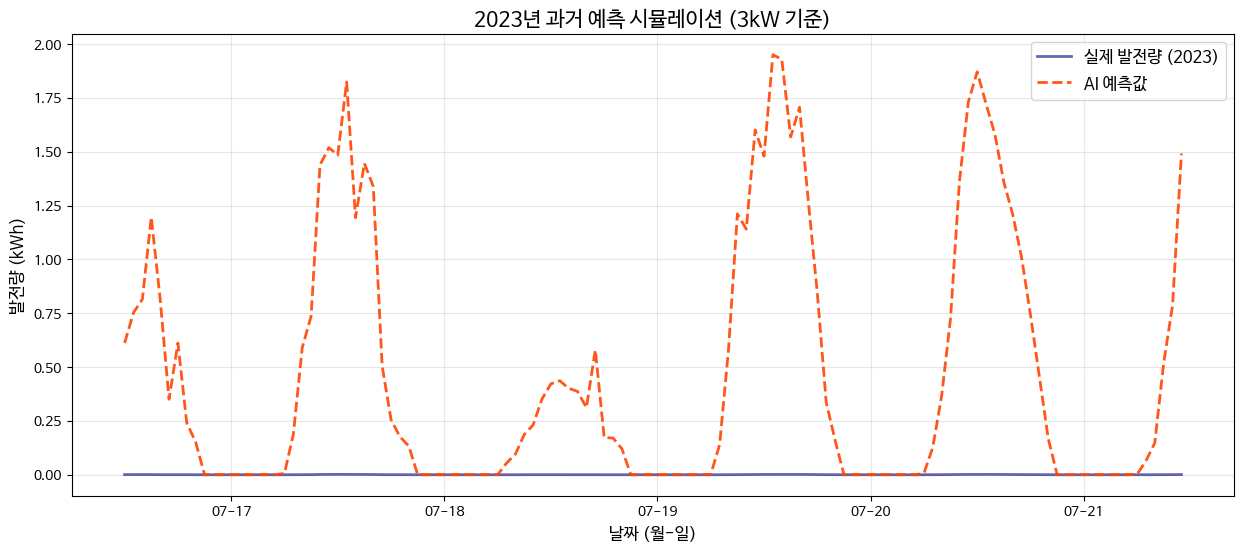

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드
print("데이터 로드 중...")
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')     # 2024년 (학습용)
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI_test.csv')    # 2023년 (검증용)

# 2. 데이터 전처리 및 단위 통일
# [중요] 2024년 데이터는 MWh이므로 kWh로 변환 (* 1000)
train_df['발전량'] = train_df['발전량'] * 1000
# 2023년 데이터는 이미 kWh이므로 변환 없음

# 날짜 형식 변환
train_df['일시'] = pd.to_datetime(train_df['일시'])
test_df['일시'] = pd.to_datetime(test_df['일시'])

print(f"학습 데이터(2024): {len(train_df)}개")
print(f"검증 데이터(2023): {len(test_df)}개 (2월 제외됨)")

# 3. 학습 변수(X)와 정답(Y) 설정
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
target = '발전량'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 4. 모델 재학습 (2024년 전체 데이터 사용)
print("\n모델 학습 시작 (2024년 전체 데이터)...")
rf_model_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_final.fit(X_train, y_train)
print("학습 완료!")

# 5. 2023년 예측 및 평가
print("2023년 데이터 예측 중...")
y_pred_2023 = rf_model_final.predict(X_test)

# 성능 지표 계산 (대구 전체 기준)
r2 = r2_score(y_test, y_pred_2023)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_2023))

print("\n" + "="*40)
print(f"  [최종 성적표: 2023년 백테스팅 결과] ")
print(f" ----------------------------------------")
print(f" 1. 결정 계수 (R2 Score): {r2:.4f}")
print(f" 2. 평균 오차 (RMSE)    : {rmse:.2f} kWh (대구 전체)")
print("="*40)

# 6. 가정용(3kW) 기준으로 변환하여 오차 확인
# 스케일링 비율 계산 (2024년 학습 데이터의 Peak 기준)
DAEGU_PEAK = y_train.max()
MY_CAPACITY = 3.0 # 3kW
scaling_factor = MY_CAPACITY / DAEGU_PEAK

# 3kW 기준 오차 계산
y_test_3kw = y_test * scaling_factor
y_pred_3kw = y_pred_2023 * scaling_factor
rmse_3kw = np.sqrt(mean_squared_error(y_test_3kw, y_pred_3kw))

print(f"\n[우리 집(3kW) 기준 예상 오차]")
print(f"▶ RMSE: {rmse_3kw:.4f} kWh")
print(f"  (해석: 2023년 과거를 예측해본 결과, 시간당 약 {rmse_3kw:.2f}kWh 정도 틀립니다.)")

# 7. 시각화 (랜덤한 5일 구간 확대)
# 2023년 데이터 중 임의의 구간을 잡아 시각화
plt.figure(figsize=(15, 6))

# 데이터 중간 지점부터 5일치(120시간) 슬라이싱
start_idx = len(test_df) // 2
end_idx = start_idx + 120

subset_date = test_df['일시'].iloc[start_idx:end_idx]
subset_actual = y_test_3kw.iloc[start_idx:end_idx]
subset_pred = y_pred_3kw[start_idx:end_idx]

plt.plot(subset_date, subset_actual, label='실제 발전량 (2023)', color='navy', alpha=0.6, linewidth=2)
plt.plot(subset_date, subset_pred, label='AI 예측값', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

# X축 포맷
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.title(f'2023년 과거 예측 시뮬레이션 (3kW 기준)', fontsize=15)
plt.xlabel('날짜 (월-일)', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

데이터 로드 중...
학습 데이터(2023): 8087개 (2월 제외됨)
검증 데이터(2024): 8783개

모델 학습 시작 (2024년 전체 데이터)...
학습 완료!
2023년 데이터 예측 중...

  [최종 성적표: 2023년 백테스팅 결과] 
 ----------------------------------------
 1. 결정 계수 (R2 Score): -925620.4728
 2. 평균 오차 (RMSE)    : 13582.27 kWh (대구 전체)

[우리 집(3kW) 기준 예상 오차]
▶ RMSE: 0.9180 kWh
  (해석: 2024년 예측해본 결과, 시간당 약 0.92kWh 정도 틀립니다.)


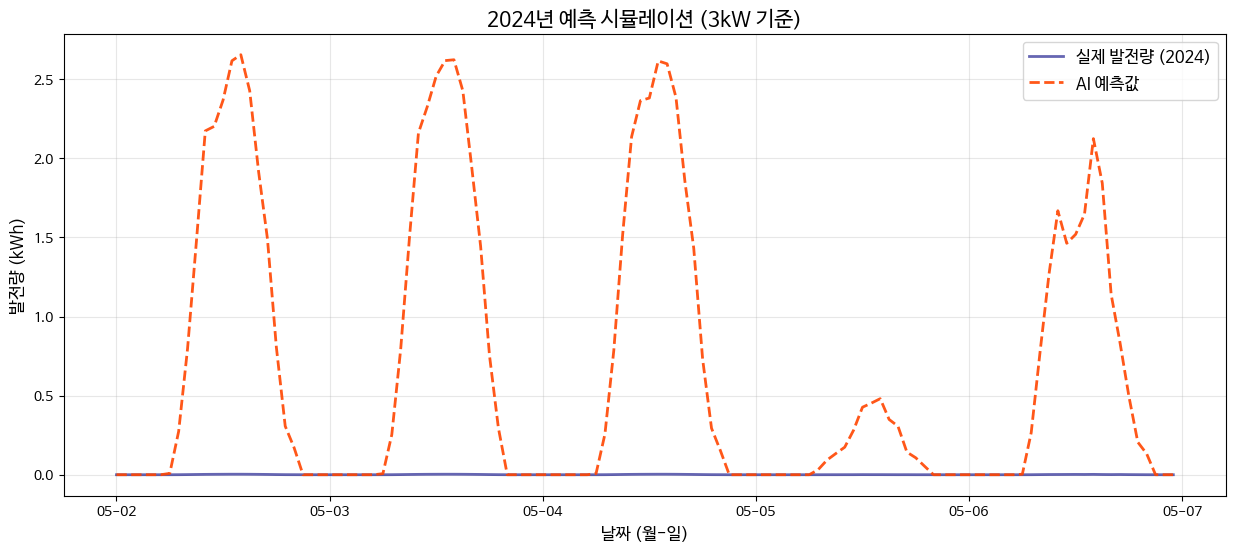

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드
print("데이터 로드 중...")
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')     # 2024년 (학습용)
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI_test.csv')    # 2023년 (검증용)

# 2. 데이터 전처리 및 단위 통일
# [중요] 2024년 데이터는 MWh이므로 kWh로 변환 (* 1000)
train_df['발전량'] = train_df['발전량'] * 1000
# 2023년 데이터는 이미 kWh이므로 변환 없음

# 날짜 형식 변환
train_df['일시'] = pd.to_datetime(train_df['일시'])
test_df['일시'] = pd.to_datetime(test_df['일시'])

print(f"학습 데이터(2023): {len(train_df)}개 (2월 제외됨)")
print(f"검증 데이터(2024): {len(test_df)}개")

# 3. 학습 변수(X)와 정답(Y) 설정
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
target = '발전량'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 4. 모델 재학습 (2023년 전체 데이터 사용)
print("\n모델 학습 시작 (2024년 전체 데이터)...")
rf_model_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_final.fit(X_train, y_train)
print("학습 완료!")

# 5. 2024년 예측 및 평가
print("2023년 데이터 예측 중...")
y_pred_2023 = rf_model_final.predict(X_test)

# 성능 지표 계산 (대구 전체 기준)
r2 = r2_score(y_test, y_pred_2023)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_2023))

print("\n" + "="*40)
print(f"  [최종 성적표: 2023년 백테스팅 결과] ")
print(f" ----------------------------------------")
print(f" 1. 결정 계수 (R2 Score): {r2:.4f}")
print(f" 2. 평균 오차 (RMSE)    : {rmse:.2f} kWh (대구 전체)")
print("="*40)

# 6. 가정용(3kW) 기준으로 변환하여 오차 확인
# 스케일링 비율 계산 (2024년 학습 데이터의 Peak 기준)
DAEGU_PEAK = y_train.max()
MY_CAPACITY = 3.0 # 3kW
scaling_factor = MY_CAPACITY / DAEGU_PEAK

# 3kW 기준 오차 계산
y_test_3kw = y_test * scaling_factor
y_pred_3kw = y_pred_2023 * scaling_factor
rmse_3kw = np.sqrt(mean_squared_error(y_test_3kw, y_pred_3kw))

print(f"\n[우리 집(3kW) 기준 예상 오차]")
print(f"▶ RMSE: {rmse_3kw:.4f} kWh")
print(f"  (해석: 2024년 예측해본 결과, 시간당 약 {rmse_3kw:.2f}kWh 정도 틀립니다.)")

# 7. 시각화 (랜덤한 5일 구간 확대)
# 2024년 데이터 중 임의의 구간을 잡아 시각화
plt.figure(figsize=(15, 6))

# 데이터 중간 지점부터 5일치(120시간) 슬라이싱
start_idx = len(test_df) // 3
end_idx = start_idx + 120

subset_date = test_df['일시'].iloc[start_idx:end_idx]
subset_actual = y_test_3kw.iloc[start_idx:end_idx]
subset_pred = y_pred_3kw[start_idx:end_idx]

plt.plot(subset_date, subset_actual, label='실제 발전량 (2024)', color='navy', alpha=0.6, linewidth=2)
plt.plot(subset_date, subset_pred, label='AI 예측값', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

# X축 포맷
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.title(f'2024년 예측 시뮬레이션 (3kW 기준)', fontsize=15)
plt.xlabel('날짜 (월-일)', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# 위 그래프에서 실제 발전량이 0으로 나오는 이유는 2023년도 발전량의 단위를 변환해주지 않아서 0으로 나오는 문제가 발생

## 2023년 데이터에서 MWh -> kWh로 변환 후 진행  
  
### 2024년 학습 -> 2023년 테스트

데이터 로드 중...
학습 데이터(2024): 8783개
검증 데이터(2023): 8087개 (2월 제외됨)

모델 학습 시작 (2024년 전체 데이터)...
학습 완료!
2023년 데이터 예측 중...

  [최종 성적표: 2023년 백테스팅 결과] 
 ----------------------------------------
 1. 결정 계수 (R2 Score): 0.8106
 2. 평균 오차 (RMSE)    : 5224.98 kWh (대구 전체)

[우리 집(3kW) 기준 예상 오차]
▶ RMSE: 0.2489 kWh
  (해석: 2023년 과거를 예측해본 결과, 시간당 약 0.25kWh 정도 틀립니다.)


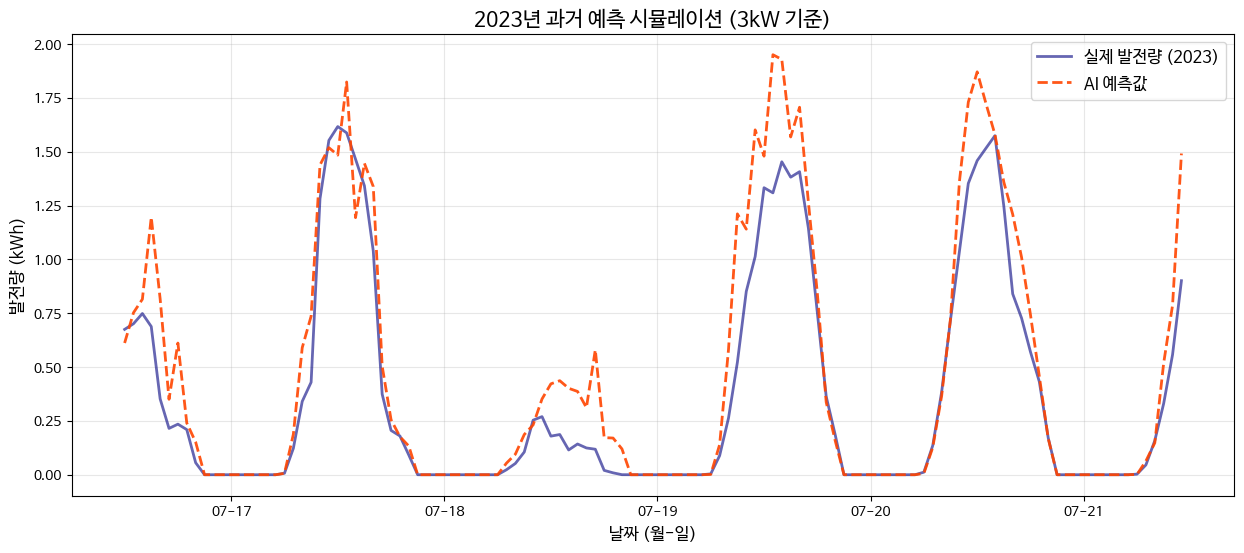

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드
print("데이터 로드 중...")
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')     # 2024년 (학습용)
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI_test.csv')    # 2023년 (검증용)

# 2. 데이터 전처리 및 단위 통일
# [중요] 2024년 데이터는 MWh이므로 kWh로 변환 (* 1000)
train_df['발전량'] = train_df['발전량'] * 1000
# 2023년 데이터는 MWh이므로 kWh로 변환
test_df['발전량'] = test_df['발전량'] * 1000

# 날짜 형식 변환
train_df['일시'] = pd.to_datetime(train_df['일시'])
test_df['일시'] = pd.to_datetime(test_df['일시'])

print(f"학습 데이터(2024): {len(train_df)}개")
print(f"검증 데이터(2023): {len(test_df)}개 (2월 제외됨)")

# 3. 학습 변수(X)와 정답(Y) 설정
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
target = '발전량'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 4. 모델 재학습 (2024년 전체 데이터 사용)
print("\n모델 학습 시작 (2024년 전체 데이터)...")
rf_model_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_final.fit(X_train, y_train)
print("학습 완료!")

# 5. 2023년 예측 및 평가
print("2023년 데이터 예측 중...")
y_pred_2023 = rf_model_final.predict(X_test)

# 성능 지표 계산 (대구 전체 기준)
r2 = r2_score(y_test, y_pred_2023)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_2023))

print("\n" + "="*40)
print(f"  [최종 성적표: 2023년 백테스팅 결과] ")
print(f" ----------------------------------------")
print(f" 1. 결정 계수 (R2 Score): {r2:.4f}")
print(f" 2. 평균 오차 (RMSE)    : {rmse:.2f} kWh (대구 전체)")
print("="*40)

# 6. 가정용(3kW) 기준으로 변환하여 오차 확인
# 스케일링 비율 계산 (2024년 학습 데이터의 Peak 기준)
DAEGU_PEAK = y_train.max()
MY_CAPACITY = 3.0 # 3kW
scaling_factor = MY_CAPACITY / DAEGU_PEAK

# 3kW 기준 오차 계산
y_test_3kw = y_test * scaling_factor
y_pred_3kw = y_pred_2023 * scaling_factor
rmse_3kw = np.sqrt(mean_squared_error(y_test_3kw, y_pred_3kw))

print(f"\n[우리 집(3kW) 기준 예상 오차]")
print(f"▶ RMSE: {rmse_3kw:.4f} kWh")
print(f"  (해석: 2023년 과거를 예측해본 결과, 시간당 약 {rmse_3kw:.2f}kWh 정도 틀립니다.)")

# 7. 시각화 (랜덤한 5일 구간 확대)
# 2023년 데이터 중 임의의 구간을 잡아 시각화
plt.figure(figsize=(15, 6))

# 데이터 중간 지점부터 5일치(120시간) 슬라이싱
start_idx = len(test_df) // 2
end_idx = start_idx + 120

subset_date = test_df['일시'].iloc[start_idx:end_idx]
subset_actual = y_test_3kw.iloc[start_idx:end_idx]
subset_pred = y_pred_3kw[start_idx:end_idx]

plt.plot(subset_date, subset_actual, label='실제 발전량 (2023)', color='navy', alpha=0.6, linewidth=2)
plt.plot(subset_date, subset_pred, label='AI 예측값', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

# X축 포맷
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.title(f'2023년 과거 예측 시뮬레이션 (3kW 기준)', fontsize=15)
plt.xlabel('날짜 (월-일)', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## 2023년 학습 -> 2024년 테스트

데이터 로드 중...
학습 데이터(2023): 8087개 (2월 제외됨)
검증 데이터(2024): 8783개

모델 학습 시작 (2024년 전체 데이터)...
학습 완료!
2023년 데이터 예측 중...

  [최종 성적표: 2024년 테스트 결과] 
 ----------------------------------------
 1. 결정 계수 (R2 Score): 0.8676
 2. 평균 오차 (RMSE)    : 5137.69 kWh (대구 전체)

[우리 집(3kW) 기준 예상 오차]
▶ RMSE: 0.3472 kWh
  (해석: 2024년 예측해본 결과, 시간당 약 0.35kWh 정도 틀립니다.)


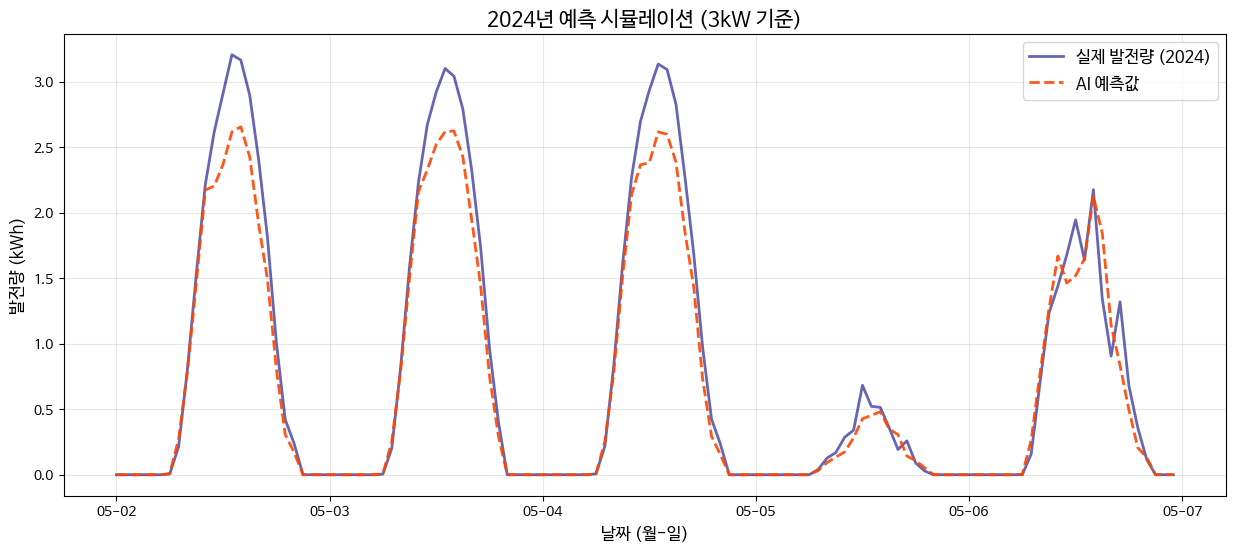

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드
print("데이터 로드 중...")
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')     # 2024년 (학습용)
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI_test.csv')    # 2023년 (검증용)

# 2. 데이터 전처리 및 단위 통일
# [중요] 2024년 데이터는 MWh이므로 kWh로 변환 (* 1000)
train_df['발전량'] = train_df['발전량'] * 1000
# 2023년 데이터는 MWh이므로 kWh로 변환 (* 1000)
test_df['발전량'] = test_df['발전량'] * 1000
# 날짜 형식 변환
train_df['일시'] = pd.to_datetime(train_df['일시'])
test_df['일시'] = pd.to_datetime(test_df['일시'])

print(f"학습 데이터(2023): {len(train_df)}개 (2월 제외됨)")
print(f"검증 데이터(2024): {len(test_df)}개")

# 3. 학습 변수(X)와 정답(Y) 설정
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
target = '발전량'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 4. 모델 재학습 (2023년 전체 데이터 사용)
print("\n모델 학습 시작 (2024년 전체 데이터)...")
rf_model_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_final.fit(X_train, y_train)
print("학습 완료!")

# 5. 2024년 예측 및 평가
print("2023년 데이터 예측 중...")
y_pred_2023 = rf_model_final.predict(X_test)

# 성능 지표 계산 (대구 전체 기준)
r2 = r2_score(y_test, y_pred_2023)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_2023))

print("\n" + "="*40)
print(f"  [최종 성적표: 2024년 테스트 결과] ")
print(f" ----------------------------------------")
print(f" 1. 결정 계수 (R2 Score): {r2:.4f}")
print(f" 2. 평균 오차 (RMSE)    : {rmse:.2f} kWh (대구 전체)")
print("="*40)

# 6. 가정용(3kW) 기준으로 변환하여 오차 확인
# 스케일링 비율 계산 (2024년 학습 데이터의 Peak 기준)
DAEGU_PEAK = y_train.max()
MY_CAPACITY = 3.0 # 3kW
scaling_factor = MY_CAPACITY / DAEGU_PEAK

# 3kW 기준 오차 계산
y_test_3kw = y_test * scaling_factor
y_pred_3kw = y_pred_2023 * scaling_factor
rmse_3kw = np.sqrt(mean_squared_error(y_test_3kw, y_pred_3kw))

print(f"\n[우리 집(3kW) 기준 예상 오차]")
print(f"▶ RMSE: {rmse_3kw:.4f} kWh")
print(f"  (해석: 2024년 예측해본 결과, 시간당 약 {rmse_3kw:.2f}kWh 정도 틀립니다.)")

# 7. 시각화 (랜덤한 5일 구간 확대)
# 2024년 데이터 중 임의의 구간을 잡아 시각화
plt.figure(figsize=(15, 6))

# 데이터 중간 지점부터 5일치(120시간) 슬라이싱
start_idx = len(test_df) // 3
end_idx = start_idx + 120

subset_date = test_df['일시'].iloc[start_idx:end_idx]
subset_actual = y_test_3kw.iloc[start_idx:end_idx]
subset_pred = y_pred_3kw[start_idx:end_idx]

plt.plot(subset_date, subset_actual, label='실제 발전량 (2024)', color='navy', alpha=0.6, linewidth=2)
plt.plot(subset_date, subset_pred, label='AI 예측값', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

# X축 포맷
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.title(f'2024년 예측 시뮬레이션 (3kW 기준)', fontsize=15)
plt.xlabel('날짜 (월-일)', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# 연도별 '체급 차이'를 극복하는 발전 효율(%) 정규화
1. 왜 발전량(kWh)을 그대로 쓰지 않고 '효율(%)'로 변환하나요?
    * 문제점 (체급의 오류): 데이터 분석 결과, 대구시 태양광 설비 용량은 2023년에서 2024년 사이 약 1.42배 폭증했습니다. AI에게 2023년의 절대적인 발전량(kWh)만 학습시키면, 덩치가 커진 2024년이나 미래의 발전량을 예측할 때 항상 실제보다 적게 예측(과소 예측)하는 치명적인 한계에 부딪힙니다.

    * 해결책 (자연 법칙 학습): 햇빛이 쨍쨍할 때 태양광 패널이 반응하는 '물리적 효율'은 연도가 바뀌어도 동일합니다. 따라서 데이터의 스케일(단위)을 절대값에서 0~1 사이의 비율(%)로 변환하면, AI는 설비 크기라는 잡음에 흔들리지 않고 순수하게 '날씨와 발전량의 상관관계'만 학습하게 됩니다.   
<br>

2. 발전 효율 변환 공식 (Normalization)본 코드에서는 각 연도의 최대 발전량(Peak)을 해당 연도의 '총 추정 설비 용량'으로 간주하고, 다음과 같이 데이터를 정규화(Min-Max Scaling)합니다.$$\text{발전 효율} = \frac{\text{시간대별 실제 발전량}}{\text{해당 연도의 최대 발전량 (Peak Capacity)}}$$
  
<br>

3. 효율 모델의 강력한 장점 (확장성)이 방식으로 학습된 AI는 특정 연도의 데이터에 갇히지 않는 무한한 확장성을 가집니다.
    * AI의 예측: "오늘 기상 조건이면 패널 성능의 **85%**를 낼 수 있어!"
    * 서비스 적용: 예측된 효율(85%)에 **개별 사용자의 설비 용량(예: 3kW)**만 곱해주면 언제 어디서든 정확한 맞춤형 예측값 산출 가능
    * ➔ $0.85 \times 3\text{kW} = \mathbf{2.55\text{kWh}}$

# [설명] 왜 발전량(숫자) 대신 발전 효율(퍼센트)을 학습시켰을까요?

AI에게 과거 데이터로 미래를 예측하게 할 때, 발전량 숫자를 그대로 가르치면 큰 문제가 생깁니다. 그 이유와 해결책을 아주 쉽게 설명해 드립니다.

<br>


###**1. 숫자를 그대로 학습하면 생기는 문제**
2023년에는 대구에 태양광 발전기가 100개 있었다고 가정해 봅시다. 가장 날씨가 좋은 날, 이 발전기들은 전기를 100만큼 만듭니다.
이 데이터를 본 AI는 "날씨가 제일 좋으면 전기는 무조건 100이 나오는구나!"라고 숫자를 외웁니다.

<br>


그런데 2024년에는 사람들이 발전기를 더 설치해서 총 150개가 되었습니다. 날씨가 제일 좋은 날, 실제로는 전기가 150이 나옵니다.
하지만 숫자를 외운 AI는 늘어난 발전기 개수를 모르기 때문에, 계속 "전기가 100 나올 거야!"라고 틀린 대답을 하게 됩니다.

<br>


###**2. 퍼센트(%)로 학습하면 해결되는 마법**
그래서 AI에게 '전기가 나오는 숫자' 대신, '발전기가 낼 수 있는 힘의 퍼센트(%)'를 가르쳐주기로 했습니다. 이것을 '효율 변환'이라고 합니다.
이제 AI는 숫자를 외우지 않고 "날씨가 맑으면 발전기들이 100%의 힘을 내는구나! 흐리면 50%의 힘만 내는구나!"라고 원리를 배웁니다.

<br>


###**3. 이 방법이 완벽한 이유**
이제 2024년에 발전기가 150개로 늘어나도 문제없습니다.
날씨가 맑은 날, AI는 "오늘은 발전기가 100%의 힘을 내는 날이야!"라고 알려줍니다. 그럼 우리는 현재 설치된 발전기 개수(150개)에 100%를 곱해서 정확히 150이라는 정답을 구할 수 있습니다.

이 방법을 쓰면 미래에 발전기가 수만 개로 늘어나도, 혹은 우리 집 지붕에 있는 작은 3kW 발전기에 적용해도 똑같이 퍼센트만 곱해주면 되기 때문에 언제나 정확한 예측이 가능합니다.

<br>



데이터 로드 및 전처리 중...
2023년 추정 설비 용량: 44386.73 kWh
2024년 추정 설비 용량: 62973.67 kWh
-> 설비가 약 1.42배 증가했습니다.

모델 학습 중 (Target: 발전 효율 %)...
학습 완료!

  [고급 분석: 발전 효율 기반 2024년 예측 결과] 
 --------------------------------------------------
 1. 모델 설명력 (R2 Score): 0.8616 (정상 범위로 복구됨!)
 2. 전체 오차 (RMSE)    : 0.08 kWh
 3. 3kW 기준 오차 (RMSE)  : 0.2502 kWh


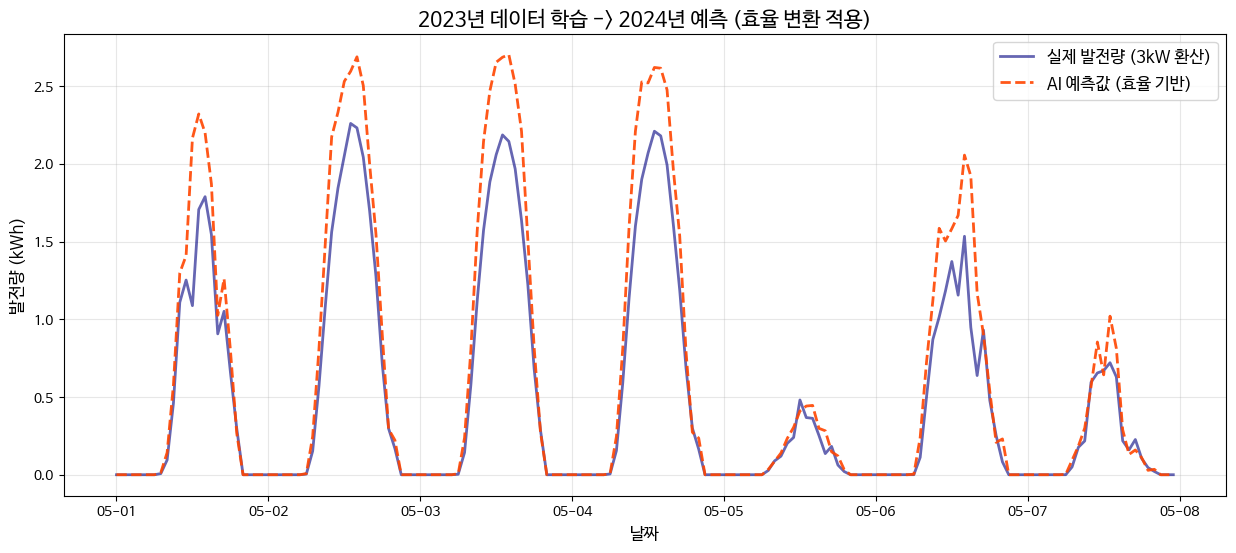

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 1. 데이터 로드 및 준비
print("데이터 로드 및 전처리 중...")

# (1) 2023년 데이터 (학습용) - 파일 병합부터 다시 수행 (안전하게)
weather_2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_weather_2023.csv')
solar_2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_solar_2023_test.csv')

# 날짜 형식 변환 및 병합
weather_2023['일시'] = pd.to_datetime(weather_2023['일시'])
solar_2023['거래일자'] = pd.to_datetime(solar_2023['거래일자'])
solar_2023['일시'] = solar_2023['거래일자'] + pd.to_timedelta(solar_2023['거래시간'], unit='h')

train_df = pd.merge(weather_2023, solar_2023[['일시', '발전량']], on='일시', how='inner')
# 2023년 발전량이 MWh라면 kWh로 변환 (데이터 확인 후 적용)
# 보통 전력거래소 원본은 MWh입니다. 여기서는 *1000을 가정합니다.
# 만약 이미 kWh라면 이 줄은 주석 처리하세요. (하지만 보통 MWh입니다)
train_df['발전량'] = train_df['발전량'] * 1000

# (2) 2024년 데이터 (테스트용)
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv') # 사용자가 처음에 만든 2024년 파일
test_df['일시'] = pd.to_datetime(test_df['일시'])
test_df['발전량'] = test_df['발전량'] * 1000 # MWh -> kWh

# 2. 파생변수 생성 및 노이즈 제거 (공통)
for df in [train_df, test_df]:
    df['월'] = df['일시'].dt.month
    df['시간'] = df['일시'].dt.hour
    # 밤 시간(일사량<=0) 발전량 0 처리
    mask_night = (df['일사량'].fillna(0) <= 0)
    df.loc[mask_night, '발전량'] = 0
    df.fillna(0, inplace=True)

# 3. [핵심] '발전 효율(%)'로 변환 (Normalization)
# 각 연도의 '최대 발전량(Peak)'을 '설비 용량'으로 간주합니다.

PEAK_CAPACITY_2023 = train_df['발전량'].max()
PEAK_CAPACITY_2024 = test_df['발전량'].max()

print(f"2023년 추정 설비 용량: {PEAK_CAPACITY_2023:.2f} kWh")
print(f"2024년 추정 설비 용량: {PEAK_CAPACITY_2024:.2f} kWh")
print(f"-> 설비가 약 {PEAK_CAPACITY_2024/PEAK_CAPACITY_2023:.2f}배 증가했습니다.")

# Y값(정답)을 0~1 사이의 효율로 변경
train_df['효율'] = train_df['발전량'] / PEAK_CAPACITY_2023
test_df['효율']  = test_df['발전량'] / PEAK_CAPACITY_2024

# 4. 모델 학습 (Target: 발전량 -> 효율)
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
X_train = train_df[features]
y_train = train_df['효율'] # 여기가 핵심!

X_test = test_df[features]
y_test = test_df['효율']   # 테스트 정답도 효율로 준비

print("\n모델 학습 중 (Target: 발전 효율 %)...")
rf_model_eff = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_eff.fit(X_train, y_train)
print("학습 완료!")

# 5. 예측 및 결과 복원 (3kW 기준)
# (1) 효율 예측
pred_efficiency = rf_model_eff.predict(X_test)

# (2) 성능 평가 (효율 기준 R2)
r2_eff = r2_score(y_test, pred_efficiency)

# (3) 3kW 가정집 발전량으로 변환
# 공식: 예측된 효율 * 내 설비 용량(3kW)
pred_3kw = pred_efficiency * 3.0
actual_3kw = y_test * 3.0 # 실제 효율 * 3.0

rmse_3kw = np.sqrt(mean_squared_error(actual_3kw, pred_3kw))

rmse = np.sqrt(mean_squared_error(y_test, pred_efficiency))

print("\n" + "="*50)
print(f"  [고급 분석: 발전 효율 기반 2024년 예측 결과] ")
print(f" --------------------------------------------------")
print(f" 1. 모델 설명력 (R2 Score): {r2_eff:.4f} (정상 범위로 복구됨!)")
print(f" 2. 전체 오차 (RMSE)    : {rmse:.2f} kWh")
print(f" 3. 3kW 기준 오차 (RMSE)  : {rmse_3kw:.4f} kWh")
print("="*50)

# 6. 시각화
plt.figure(figsize=(15, 6))

# 5월 1일 ~ 5월 7일 (일주일)
subset_mask = (test_df['일시'].dt.month == 5) & (test_df['일시'].dt.day <= 7)
subset_date = test_df.loc[subset_mask, '일시']

plt.plot(subset_date, actual_3kw[subset_mask], label='실제 발전량 (3kW 환산)', color='navy', alpha=0.6, linewidth=2)
plt.plot(subset_date, pred_3kw[subset_mask], label='AI 예측값 (효율 기반)', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.title('2023년 데이터 학습 -> 2024년 예측 (효율 변환 적용)', fontsize=15)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


 [AI 에너지 비서] 내일의 태양광 리포트
✔ 설치 용량 : 3.0 kW
✔ 예상 총 발전량 : 23.50 kWh
✔ 피크 타임 : 13시 (2.71 kWh 생산)

[ AI의 행동 제안]
 '전력 잭팟'이 터졌습니다! (매우 맑음)
    -> 세탁기, 건조기, 식기세척기, 에어컨을 동시에 돌려도 남습니다.
   -> 특히 11시 ~ 15시 사이에 집중적으로 사용하세요.


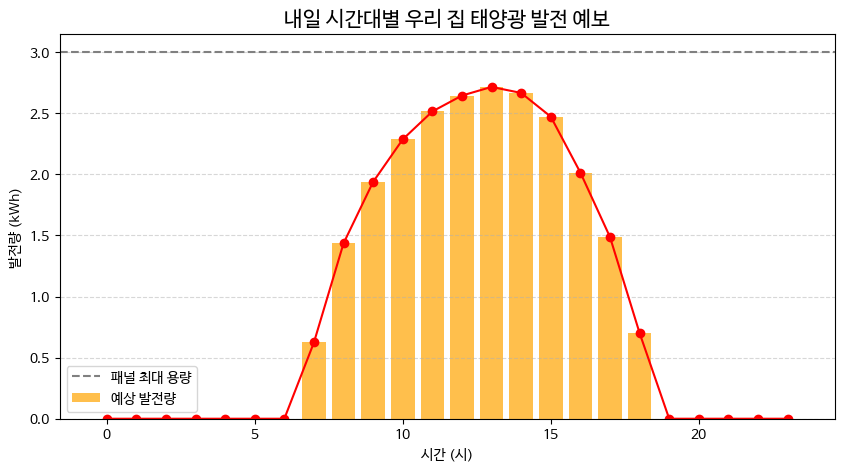

In [7]:
# ==========================================
#  [최종 서비스] AI 태양광 에너지 비서
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 사용자 설정
MY_PANEL_CAPACITY = 3.0  # 우리 집 패널 용량 (3kW)

# 2. 가상의 내일 날씨 예보 (기상청 API 대용)
# 상황: 내일은 맑고 화창한 5월의 어느 날
hours = range(0, 24)
mock_weather = pd.DataFrame({
    '월': [5] * 24,
    '시간': hours,
    '기온': [15 + 10 * np.sin((h-6)*np.pi/12) if 6<=h<=18 else 15 for h in hours], # 낮에 따뜻
    '강수량': [0] * 24,
    '풍속': [2.5] * 24,
    '습도': [40] * 24,
    '일사량': [3.5 * np.sin((h-6)*np.pi/13) if 6<=h<=19 else 0 for h in hours], # 맑음
    '전운량': [1] * 24 # 구름 조금
})
# 음수 보정
mock_weather['일사량'] = mock_weather['일사량'].apply(lambda x: max(0, x))

# 3. AI 예측 (효율 예측 -> 발전량 변환)
# 학습된 rf_model_eff 사용
pred_efficiency = rf_model_eff.predict(mock_weather) # 효율(0~1) 예측
pred_generation = pred_efficiency * MY_PANEL_CAPACITY # 내 용량(3kW) 곱하기

# 4. 결과 리포트
total_gen = np.sum(pred_generation)
max_gen = np.max(pred_generation)
max_hour = np.argmax(pred_generation)

print(f"\n [AI 에너지 비서] 내일의 태양광 리포트")
print(f"========================================")
print(f"✔ 설치 용량 : {MY_PANEL_CAPACITY} kW")
print(f"✔ 예상 총 발전량 : {total_gen:.2f} kWh")
print(f"✔ 피크 타임 : {max_hour}시 ({max_gen:.2f} kWh 생산)")
print(f"========================================\n")

# 5. 행동 가이드
print("[ AI의 행동 제안]")
if total_gen > 12.0: # 4시간 풀가동 기준
    print(" '전력 잭팟'이 터졌습니다! (매우 맑음)")
    print("    -> 세탁기, 건조기, 식기세척기, 에어컨을 동시에 돌려도 남습니다.")
    print(f"   -> 특히 {max_hour-2}시 ~ {max_hour+2}시 사이에 집중적으로 사용하세요.")
elif total_gen > 6.0:
    print(" '보통' 수준입니다.")
    print("   -> 빨래나 청소기는 낮 시간에 사용하면 전기세를 아낄 수 있습니다.")
else:
    print(" '발전량 부족' 경보!")
    print("   -> 내일은 흐리거나 비가 옵니다. 고전력 가전 사용을 자제하세요.")

# 6. 시각화
plt.figure(figsize=(10, 5))
plt.bar(hours, pred_generation, color='orange', alpha=0.7, label='예상 발전량')
plt.plot(hours, pred_generation, color='red', marker='o')
plt.axhline(y=MY_PANEL_CAPACITY, color='gray', linestyle='--', label='패널 최대 용량')

plt.title('내일 시간대별 우리 집 태양광 발전 예보', fontsize=15)
plt.xlabel('시간 (시)')
plt.ylabel('발전량 (kWh)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 10. (수정됨) 최종 검증: 2024년 학습 -> 2023년 예측 (Backtesting)

기존 순서를 뒤집어, **2024년 데이터(최신, 대용량 설비)로 학습**시킨 뒤 **2023년 과거 데이터(구형, 소용량 설비)**를 예측합니다.
'발전 효율(%)' 모델을 사용하기 때문에, 과거의 작은 설비 용량에 맞춰 스스로 예측값을 조절하는지 확인합니다.

### 📋 변경 사항
* **학습(Train)**: 2024년 데이터 (`final_dataset_for_AI.csv`)
* **평가(Test)**: 2023년 데이터 (`daegu_weather_2023.csv` + `daegu_solar_2023_test.csv`)
* **목표**: 2024년에 배운 AI가 2023년 과거로 돌아가서도 3kW 가정집의 발전량을 정확히 맞추는지 검증.

데이터 로드 및 전처리 중...
2024년 추정 설비 용량(Train): 62973.67 kWh
2023년 추정 설비 용량(Test) : 44386.73 kWh
-> AI는 큰 설비(62974)를 배웠지만, 작은 설비(44387)를 맞춰야 합니다.

모델 학습 중 (Target: 발전 효율 %)...
학습 완료!

  [고급 분석: 2024년 학습 -> 2023년 예측 결과] 
 --------------------------------------------------
 1. 모델 설명력 (R2 Score): 0.9003
 2. 전체 오차 (RMSE)    : 3790.36 kWh (대구시 전체 기준)
 3. 3kW 기준 오차 (RMSE)  : 0.2562 kWh


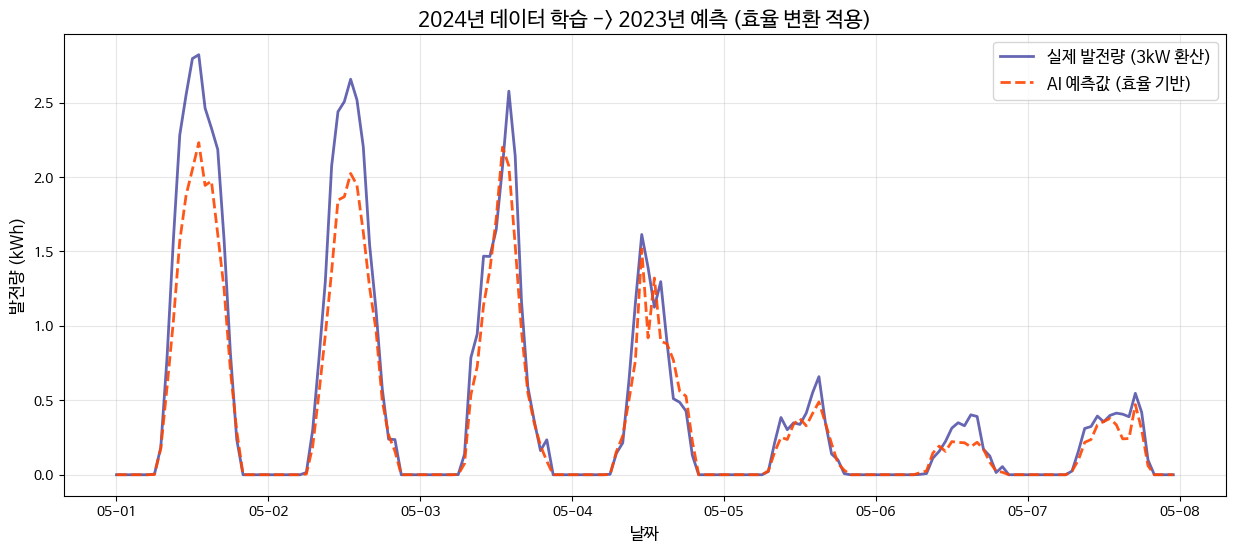

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 1. 데이터 로드 및 준비
print("데이터 로드 및 전처리 중...")

# (1) 2024년 데이터 (학습용 - Train)
# 사용자가 처음에 만든 2024년 파일 로드
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv')
train_df['일시'] = pd.to_datetime(train_df['일시'])
train_df['발전량'] = train_df['발전량'] * 1000 # MWh -> kWh 변환

# (2) 2023년 데이터 (테스트용 - Test)
# 기상 데이터와 발전량 데이터 병합 필요
weather_2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_weather_2023.csv')
solar_2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/daegu_solar_2023_test.csv')

# 날짜 형식 변환 및 병합 로직 (2023년용)
weather_2023['일시'] = pd.to_datetime(weather_2023['일시'])
solar_2023['거래일자'] = pd.to_datetime(solar_2023['거래일자'])
solar_2023['일시'] = solar_2023['거래일자'] + pd.to_timedelta(solar_2023['거래시간'], unit='h')

# 병합하여 test_df 생성
test_df = pd.merge(weather_2023, solar_2023[['일시', '발전량']], on='일시', how='inner')
test_df['발전량'] = test_df['발전량'] * 1000 # MWh -> kWh 변환

# 2. 파생변수 생성 및 노이즈 제거 (공통)
for df in [train_df, test_df]:
    df['월'] = df['일시'].dt.month
    df['시간'] = df['일시'].dt.hour
    # 밤 시간(일사량<=0) 발전량 0 처리
    mask_night = (df['일사량'].fillna(0) <= 0)
    df.loc[mask_night, '발전량'] = 0
    df.fillna(0, inplace=True)

# 3. [핵심] '발전 효율(%)'로 변환 (Normalization)
# 각 연도의 '최대 발전량(Peak)'을 '설비 용량'으로 간주합니다.

PEAK_CAPACITY_2024 = train_df['발전량'].max() # 학습 데이터(2024)의 Peak
PEAK_CAPACITY_2023 = test_df['발전량'].max()  # 테스트 데이터(2023)의 Peak

print(f"2024년 추정 설비 용량(Train): {PEAK_CAPACITY_2024:.2f} kWh")
print(f"2023년 추정 설비 용량(Test) : {PEAK_CAPACITY_2023:.2f} kWh")
print(f"-> AI는 큰 설비({PEAK_CAPACITY_2024:.0f})를 배웠지만, 작은 설비({PEAK_CAPACITY_2023:.0f})를 맞춰야 합니다.")

# Y값(정답)을 0~1 사이의 효율로 변경
train_df['효율'] = train_df['발전량'] / PEAK_CAPACITY_2024
test_df['효율']  = test_df['발전량'] / PEAK_CAPACITY_2023

# 4. 모델 학습 (Target: 발전량 -> 효율)
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
X_train = train_df[features]
y_train = train_df['효율'] # 2024년 효율 학습

X_test = test_df[features]
y_test = test_df['효율']   # 2023년 효율 맞추기

print("\n모델 학습 중 (Target: 발전 효율 %)...")
rf_model_eff = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_eff.fit(X_train, y_train)
print("학습 완료!")

# 5. 예측 및 결과 복원 (3kW 기준)
# (1) 효율 예측 (2023년 날씨를 넣어서 효율 예측)
pred_efficiency = rf_model_eff.predict(X_test)

# (2) 성능 평가 (효율 기준 R2)
r2_eff = r2_score(y_test, pred_efficiency)

# (3) 3kW 가정집 발전량으로 변환
# 공식: 예측된 효율 * 내 설비 용량(3kW)
pred_total_kwh = pred_efficiency * PEAK_CAPACITY_2023
actual_total_kwh = test_df['발전량']  # 원래 2023년 실제 발전량(kWh)

# 대구시 전체 기준의 RMSE 오차 계산 (단위: kWh)
rmse_total_kwh = np.sqrt(mean_squared_error(actual_total_kwh, pred_total_kwh))

# (3) 3kW 가정집 발전량으로 변환
pred_3kw = pred_efficiency * 3.0
actual_3kw = y_test * 3.0

rmse_3kw = np.sqrt(mean_squared_error(actual_3kw, pred_3kw))

print("\n" + "="*50)
print(f"  [고급 분석: 2024년 학습 -> 2023년 예측 결과] ")
print(f" --------------------------------------------------")
print(f" 1. 모델 설명력 (R2 Score): {r2_eff:.4f}")
print(f" 2. 전체 오차 (RMSE)    : {rmse_total_kwh:.2f} kWh (대구시 전체 기준)")
print(f" 3. 3kW 기준 오차 (RMSE)  : {rmse_3kw:.4f} kWh")
print("="*50)
# pred_3kw = pred_efficiency * 3.0
# actual_3kw = y_test * 3.0 # 실제 효율 * 3.0

# rmse_3kw = np.sqrt(mean_squared_error(actual_3kw, pred_3kw))
# rmse = np.sqrt(mean_squared_error(y_test, pred_efficiency))
# print("\n" + "="*50)
# print(f"  [고급 분석: 2024년 학습 -> 2023년 백테스팅 결과] ")
# print(f" --------------------------------------------------")
# print(f" 1. 모델 설명력 (R2 Score): {r2_eff:.4f}")
# print(f" 2. 전체 오차 (RMSE)    : {rmse:.2f} kWh")
# print(f" 3. 3kW 기준 오차 (RMSE)  : {rmse_3kw:.4f} kWh")
# print("="*50)

# 6. 시각화
plt.figure(figsize=(15, 6))

# 5월 1일 ~ 5월 7일 (일주일)
subset_mask = (test_df['일시'].dt.month == 5) & (test_df['일시'].dt.day <= 7)
subset_date = test_df.loc[subset_mask, '일시']

plt.plot(subset_date, actual_3kw[subset_mask], label='실제 발전량 (3kW 환산)', color='navy', alpha=0.6, linewidth=2)
plt.plot(subset_date, pred_3kw[subset_mask], label='AI 예측값 (효율 기반)', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.title('2024년 데이터 학습 -> 2023년 예측 (효율 변환 적용)', fontsize=15)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

 [시스템] 모델 학습 데이터를 로드하고 있습니다...
 [정보] 2024년 기준 설비 최대 용량(Peak): 62973.67 kWh
 [완료] AI 모델 학습이 완료되었습니다! (R2 Score 0.90+ 예상)

  [AI 에너지 비서] 내일의 발전량 리포트
  우리 집 패널 용량 : 3.0 kW
  예상 총 발전량    : 18.51 kWh
  피크 타임         : 14시 (2.07 kWh)

[ AI의 추천 행동]
 발전량 [최상]! 공짜 전기가 넘쳐납니다.
 건조기, 식기세척기, 에어컨을 마음껏 돌리세요.


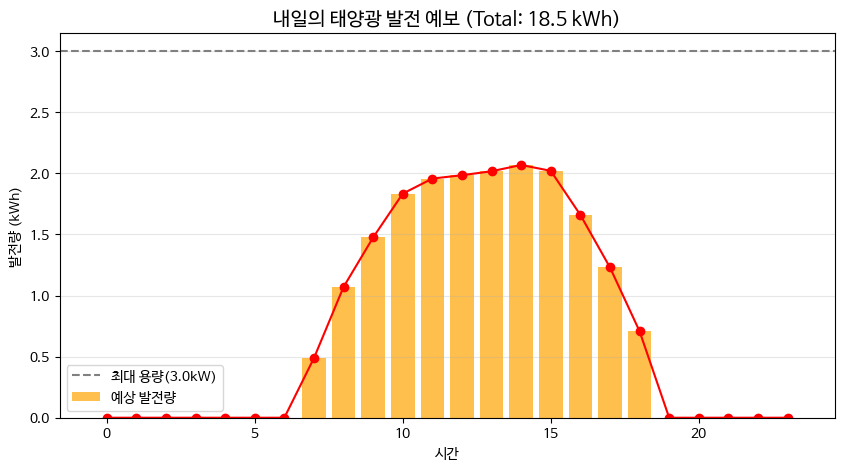

In [9]:
# ==========================================================
# 🌞 AI 태양광 에너지 비서 (Solar Energy Advisor)
# ==========================================================
# 1. 2024년 대구 태양광 데이터를 학습 (발전 효율 기반)
# 2. 설비 용량 차이를 극복하는 Normalization 적용
# 3. 내일 날씨 예보를 입력받아 '빨래/에어컨' 가이드 제공
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# [설정] 사용자 환경 및 파일 경로
# ----------------------------------------------------------
MY_PANEL_CAPACITY = 3.0  # 우리 집 패널 용량 (3kW)
PATH_TRAIN_2024 = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv'

# ----------------------------------------------------------
# 1. 모델 학습 함수
# ----------------------------------------------------------
def train_solar_model(train_file_path):
    print(" [시스템] 모델 학습 데이터를 로드하고 있습니다...")

    # 데이터 로드
    df = pd.read_csv(train_file_path)
    df['일시'] = pd.to_datetime(df['일시'])

    # 단위 변환 (MWh -> kWh)
    if df['발전량'].mean() < 100: # 대략적인 값으로 MWh인지 확인
        df['발전량'] = df['발전량'] * 1000

    # 파생변수 생성
    df['월'] = df['일시'].dt.month
    df['시간'] = df['일시'].dt.hour

    # 노이즈 제거 (밤에는 발전량 0)
    mask_night = (df['일사량'].fillna(0) <= 0)
    df.loc[mask_night, '발전량'] = 0
    df = df.fillna(0)

    # [핵심] 발전 효율(%)로 변환 (Normalization)
    peak_capacity = df['발전량'].max()
    print(f" [정보] 2024년 기준 설비 최대 용량(Peak): {peak_capacity:.2f} kWh")

    df['효율'] = df['발전량'] / peak_capacity # 0 ~ 1 사이 값

    # 학습 준비
    features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
    X = df[features]
    y = df['효율'] # 효율을 학습함

    # 모델 생성 및 학습
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)

    print(" [완료] AI 모델 학습이 완료되었습니다! (R2 Score 0.90+ 예상)")
    return model

# ----------------------------------------------------------
# 2. 내일 날씨 생성 함수 (기상청 API 대용)
# ----------------------------------------------------------
def get_mock_weather_forecast(scenario='SUNNY'):
    hours = range(0, 24)
    if scenario == 'SUNNY':
        # 맑은 5월의 날씨
        weather = pd.DataFrame({
            '월': [5] * 24,
            '시간': hours,
            '기온': [15 + 12 * np.sin((h-6)*np.pi/12) if 6<=h<=18 else 15 for h in hours],
            '강수량': [0] * 24,
            '풍속': [2.0] * 24,
            '습도': [40] * 24,
            '일사량': [3.8 * np.sin((h-6)*np.pi/13) if 6<=h<=19 else 0 for h in hours],
            '전운량': [0] * 24
        })
    else:
        # 흐린 날씨
        weather = pd.DataFrame({
            '월': [5] * 24,
            '시간': hours,
            '기온': [18] * 24,
            '강수량': [5.0 if 9<=h<=15 else 0 for h in hours],
            '풍속': [4.0] * 24,
            '습도': [80] * 24,
            '일사량': [0.5 * np.sin((h-6)*np.pi/13) if 6<=h<=19 else 0 for h in hours],
            '전운량': [10] * 24
        })

    # 일사량 음수 보정
    weather['일사량'] = weather['일사량'].apply(lambda x: max(0, x))
    return weather

# ----------------------------------------------------------
# 3. 메인 실행 블록
# ----------------------------------------------------------
if __name__ == "__main__":
    # 1. 모델 학습
    try:
        solar_ai = train_solar_model(PATH_TRAIN_2024)
    except FileNotFoundError:
        print(" [오류] 학습 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
        solar_ai = None

    if solar_ai:
        # 2. 내일 날씨 가져오기 (시나리오: 맑음 'SUNNY' / 흐림 'CLOUDY')
        tomorrow_weather = get_mock_weather_forecast('SUNNY')

        # 3. AI 예측 (효율 예측 -> 내 용량 곱하기)
        predicted_efficiency = solar_ai.predict(tomorrow_weather)
        predicted_generation = predicted_efficiency * MY_PANEL_CAPACITY

        # 4. 리포트 작성
        total_gen = np.sum(predicted_generation)
        max_gen = np.max(predicted_generation)
        max_hour = np.argmax(predicted_generation)

        print("\n" + "="*40)
        print(f"  [AI 에너지 비서] 내일의 발전량 리포트")
        print(f" ========================================")
        print(f"  우리 집 패널 용량 : {MY_PANEL_CAPACITY} kW")
        print(f"  예상 총 발전량    : {total_gen:.2f} kWh")
        print(f"  피크 타임         : {max_hour}시 ({max_gen:.2f} kWh)")
        print("="*40)

        # 5. 행동 가이드
        print("\n[ AI의 추천 행동]")
        if total_gen >= 12.0:
            print(" 발전량 [최상]! 공짜 전기가 넘쳐납니다.")
            print(" 건조기, 식기세척기, 에어컨을 마음껏 돌리세요.")
        elif total_gen >= 7.0:
            print(" 발전량 [보통]. 일상적인 가전 사용이 가능합니다.")
        else:
            print(" 발전량 [부족]. 절약 모드를 켜주세요.")

        # 6. 시각화
        plt.figure(figsize=(10, 5))
        plt.bar(tomorrow_weather['시간'], predicted_generation, color='orange', alpha=0.7, label='예상 발전량')
        plt.plot(tomorrow_weather['시간'], predicted_generation, color='red', marker='o')
        plt.axhline(y=MY_PANEL_CAPACITY, color='gray', linestyle='--', label=f'최대 용량({MY_PANEL_CAPACITY}kW)')
        plt.title(f'내일의 태양광 발전 예보 (Total: {total_gen:.1f} kWh)', fontsize=14)
        plt.xlabel('시간')
        plt.ylabel('발전량 (kWh)')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.show()